**STEP 01  IMPORT LIBRARIES**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

**STEP 02 LOAD DATASET**

In [2]:
df = pd.read_csv("engineered_accessibility_dataset.csv")

**STEP 03 ENCODE TARGET**

In [3]:
encoder = LabelEncoder()

df["Accessibility_Category"] = encoder.fit_transform(
    df["Accessibility_Category"]
)

**STEP 04 FEATURES**

In [4]:
X = df.drop(columns=[
    "Accessibility_Score",
    "Accessibility_Category",
    "Improvement_Priority",
    "Location_ID",
    "Location_Name"
], errors="ignore")

y = df["Accessibility_Category"]

**STEP 05 STANDARDIZATION**

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**PCA**

**STEP 06**

In [6]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

**STEP 07**

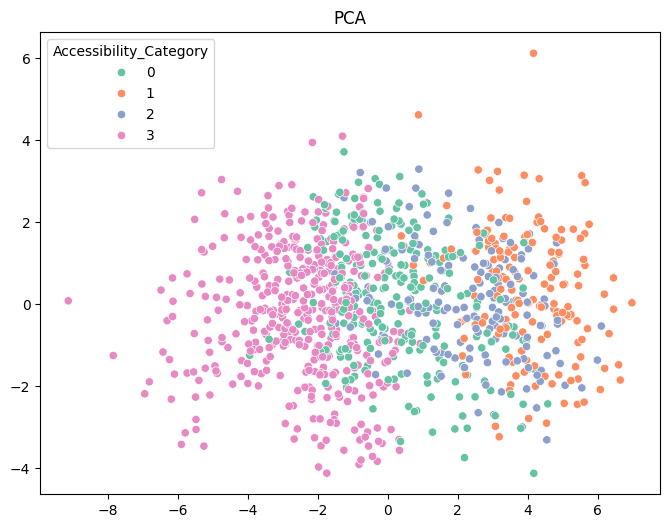

In [7]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=y,
    palette="Set2"
)

plt.title("PCA")

plt.show()

**STEP 08**

In [8]:
print("Explained Variance")

print(pca.explained_variance_ratio_)

print()

print("Total")

print(pca.explained_variance_ratio_.sum())

Explained Variance
[0.18858693 0.05171474]

Total
0.2403016728172975


**LDA**

**STEP 09**

In [9]:
lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

**STEP 10**

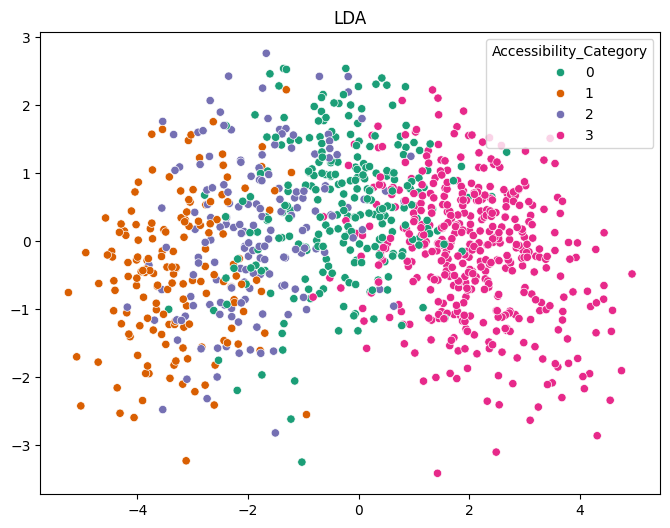

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_lda[:,0],
    y=X_lda[:,1],
    hue=y,
    palette="Dark2"
)

plt.title("LDA")

plt.show()

# **SVD**

**STEP 11**

In [11]:
svd = TruncatedSVD(
    n_components=2,
    random_state=42
)

X_svd = svd.fit_transform(X_scaled)

**STEP 12**

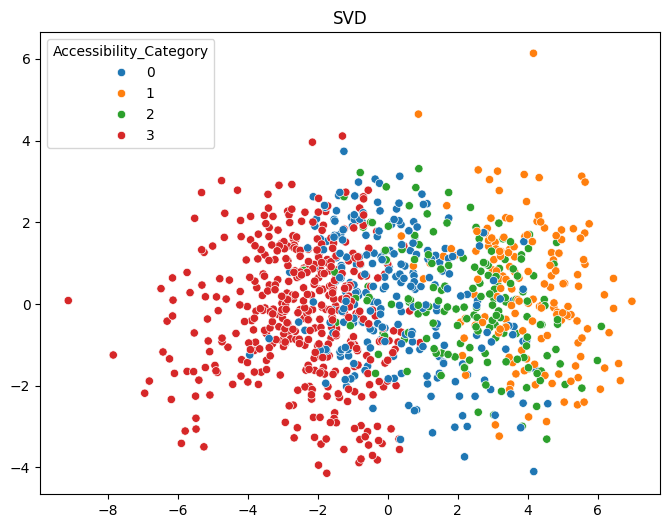

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_svd[:,0],
    y=X_svd[:,1],
    hue=y,
    palette="tab10"
)

plt.title("SVD")

plt.show()

# **CLASSIFICATION COMPARISON**

**STEP 13**

In [13]:
def evaluate_dimension_reduction(data, name):

    X_train, X_test, y_train, y_test = train_test_split(
        data,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    prediction = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    print(name)

    print("Accuracy:", round(accuracy,3))

    print("----------------")

**STEP 14**

In [14]:
evaluate_dimension_reduction(
    X_pca,
    "PCA"
)

evaluate_dimension_reduction(
    X_lda,
    "LDA"
)

evaluate_dimension_reduction(
    X_svd,
    "SVD"
)

PCA
Accuracy: 0.605
----------------
LDA
Accuracy: 0.72
----------------
SVD
Accuracy: 0.595
----------------


**VISUALIZATION**

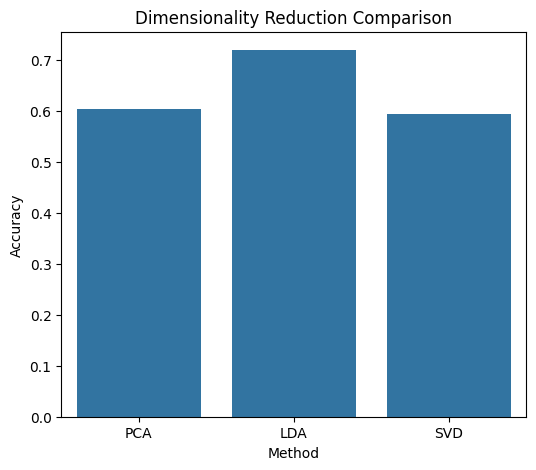

In [15]:
results = pd.DataFrame({

    "Method": ["PCA", "LDA", "SVD"],

    "Accuracy": [

        accuracy_score(
            train_test_split(X_pca, y, test_size=0.20, random_state=42, stratify=y)[3],
            RandomForestClassifier(random_state=42).fit(
                train_test_split(X_pca, y, test_size=0.20, random_state=42, stratify=y)[0],
                train_test_split(X_pca, y, test_size=0.20, random_state=42, stratify=y)[2]
            ).predict(
                train_test_split(X_pca, y, test_size=0.20, random_state=42, stratify=y)[1]
            )
        ),

        accuracy_score(
            train_test_split(X_lda, y, test_size=0.20, random_state=42, stratify=y)[3],
            RandomForestClassifier(random_state=42).fit(
                train_test_split(X_lda, y, test_size=0.20, random_state=42, stratify=y)[0],
                train_test_split(X_lda, y, test_size=0.20, random_state=42, stratify=y)[2]
            ).predict(
                train_test_split(X_lda, y, test_size=0.20, random_state=42, stratify=y)[1]
            )
        ),

        accuracy_score(
            train_test_split(X_svd, y, test_size=0.20, random_state=42, stratify=y)[3],
            RandomForestClassifier(random_state=42).fit(
                train_test_split(X_svd, y, test_size=0.20, random_state=42, stratify=y)[0],
                train_test_split(X_svd, y, test_size=0.20, random_state=42, stratify=y)[2]
            ).predict(
                train_test_split(X_svd, y, test_size=0.20, random_state=42, stratify=y)[1]
            )
        )

    ]

})

plt.figure(figsize=(6,5))

sns.barplot(
    x="Method",
    y="Accuracy",
    data=results
)

plt.title("Dimensionality Reduction Comparison")

plt.show()